--- Generating Dynamic Profile Evolution: Monthly Reclassification ---


Step 1: Reclassifying profiles for every record...


Success! Dynamic evolution chart saved at: ..\figuras\figure-dynamic-profile-evolution-validation-en.pdf


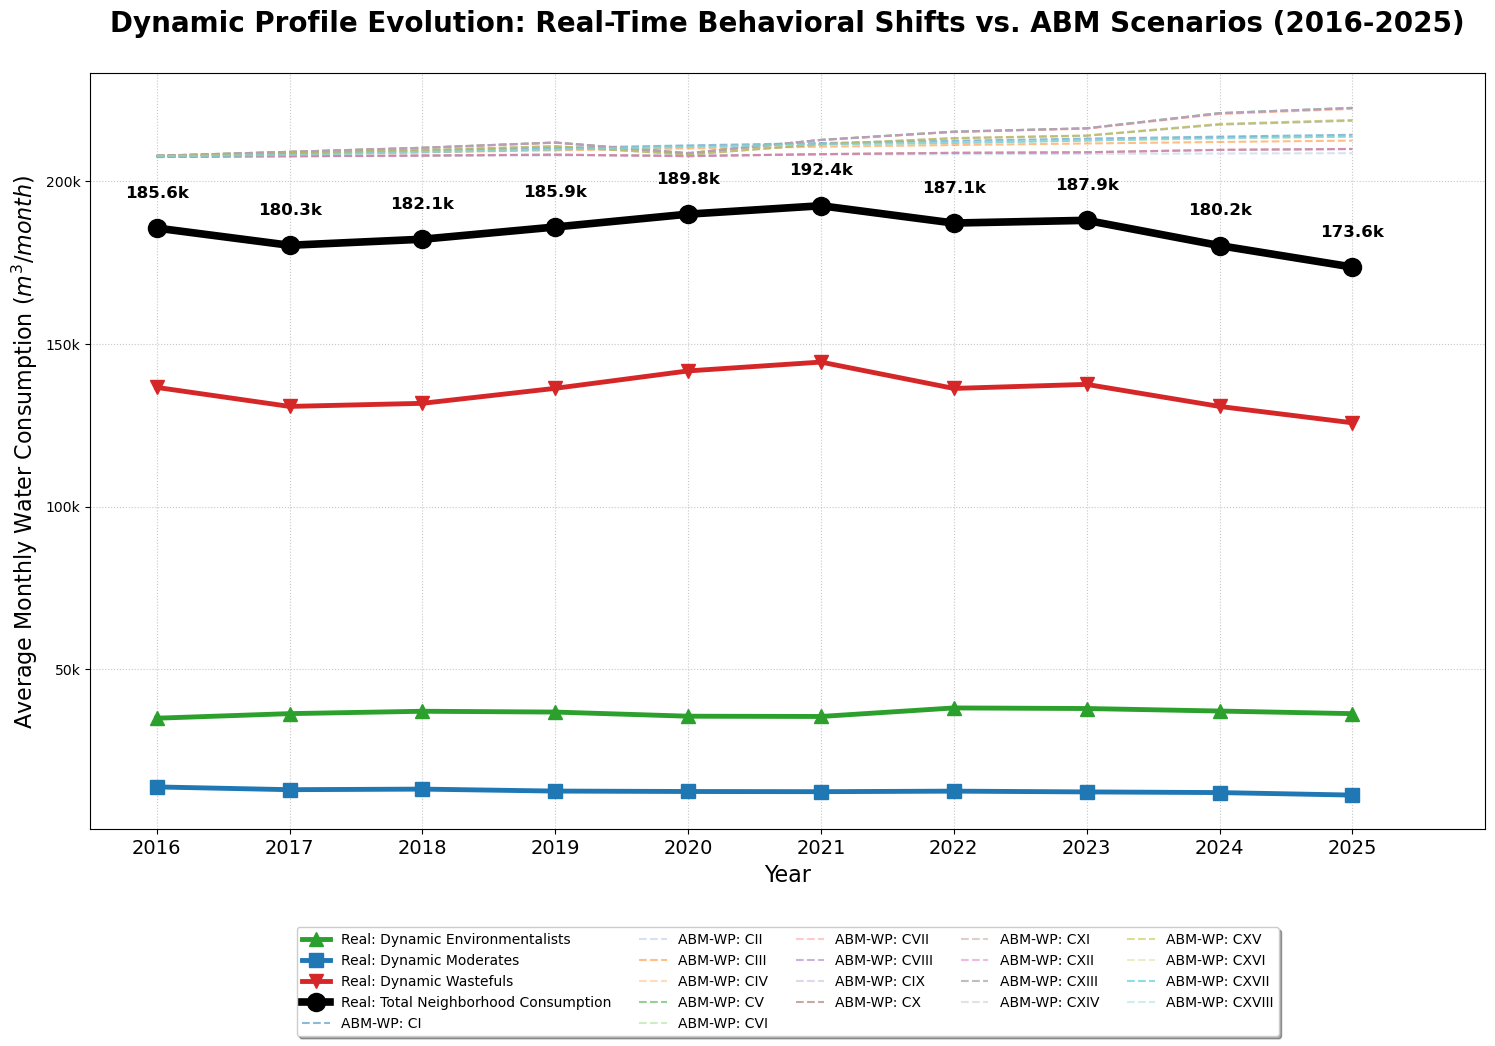

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
BASELINE_FILE = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv'
HISTORY_120M = 'Tabela_consumo_Itapua_120m.csv'
TOTAL_HISTORY_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-dynamic-profile-evolution-validation-en.pdf'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')

# Classification Thresholds (Same as GAMA)
def classify_profile(daily_liters):
    if daily_liters < 100.0:
        return 'AMBIENTALISTA'
    elif daily_liters <= 121.5:
        return 'MODERADO'
    else:
        return 'PERDULARIO'

def aggregate_annually_mean(df, date_col, value_cols):
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].mean().reset_index()

def main():
    print("--- Generating Dynamic Profile Evolution: Monthly Reclassification ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load Real Total (The standard reference line)
    path_total = os.path.join(INPUT_DIR_INCLUDES, TOTAL_HISTORY_FILE)
    df_total_ref = pd.read_csv(path_total, sep=';', decimal='.')
    df_total_ref['Date'] = pd.to_datetime(df_total_ref['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_total_ref.rename(columns={'real_total_consumption':'VL_TOTAL_CONSUMO'}, inplace=True)

    # B. Load Residents (To calculate L/p/day in each month)
    path_baseline = os.path.join(INPUT_DIR_INCLUDES, BASELINE_FILE)
    df_residents = pd.read_csv(path_baseline, sep=';')[['SK_MATRICULA', 'NN_MORADORES_ANALISE']]
    
    # C. Load Consumption History (120m)
    path_120m = os.path.join(INPUT_DIR_INCLUDES, 'dados', HISTORY_120M)
    df_120m = pd.read_csv(path_120m, sep=';')
    df_120m['AM_REFERENCIA'] = df_120m['AM_REFERENCIA'].astype(int)
    df_120m = df_120m[(df_120m['AM_REFERENCIA'] >= 201601) & (df_120m['AM_REFERENCIA'] <= 202512)]

    # D. DYNAMIC RECLASSIFICATION (METER BY METER, MONTH BY MONTH)
    print("Step 1: Reclassifying profiles for every record...")
    df_dynamic = pd.merge(df_120m, df_residents, on='SK_MATRICULA', how='inner')
    
    # Calculate daily liters per capita for THIS specific month
    df_dynamic['L_P_DAY'] = (df_dynamic['HCLQTCON'] * 1000 / df_dynamic['NN_MORADORES_ANALISE']) / 30.5
    
    # Assign Profile based on THAT month's consumption
    df_dynamic['DYNAMIC_PROFILE'] = df_dynamic['L_P_DAY'].apply(classify_profile)

    # E. Calculate Proportions of the Dynamic Groups
    monthly_dynamic_sum = df_dynamic.groupby(['AM_REFERENCIA', 'DYNAMIC_PROFILE'])['HCLQTCON'].sum().unstack(fill_value=0)
    monthly_prop = monthly_dynamic_sum.div(monthly_dynamic_sum.sum(axis=1), axis=0)
    
    # F. Scale to Real Neighborhood Total
    df_real_final = pd.merge(df_total_ref, monthly_prop, on='AM_REFERENCIA', how='inner')
    profiles_list = ['AMBIENTALISTA', 'MODERADO', 'PERDULARIO']
    for p in profiles_list:
        if p in df_real_final.columns:
            df_real_final[p] = df_real_final['VL_TOTAL_CONSUMO'] * df_real_final[p]
        else:
            df_real_final[p] = 0.0

    # G. Load ABM Results and Aggregate Annually
    path_sim = os.path.join(INPUT_DIR_RESULTS, SIM_FILE)
    df_sim = pd.read_csv(path_sim, sep=';', decimal=',')
    df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    sim_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    df_real_annual = aggregate_annually_mean(df_real_final, 'Date', ['VL_TOTAL_CONSUMO'] + profiles_list)
    df_sim_annual = aggregate_annually_mean(df_sim, 'Date', sim_cols)

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 12))

    # --- 1. Plot Simulation Scenarios (Dashed) ---
    sim_palette = plt.cm.tab20(np.linspace(0, 1, len(sim_cols)))
    for i, col in enumerate(sim_cols):
        scen_id = col.split('_')[0]
        ax.plot(df_sim_annual['Year'], df_sim_annual[col], color=sim_palette[i],
                linestyle='--', linewidth=1.5, alpha=0.5, zorder=5, label=f"ABM-WP: {scen_id}")

    # --- 2. Plot Dynamic Real Profiles (Solid) ---
    profile_styles = {
        'AMBIENTALISTA': {'color': '#2ca02c', 'label': 'Real: Dynamic Environmentalists', 'marker': '^'},
        'MODERADO': {'color': '#1f77b4', 'label': 'Real: Dynamic Moderates', 'marker': 's'},
        'PERDULARIO': {'color': '#d62728', 'label': 'Real: Dynamic Wastefuls', 'marker': 'v'}
    }
    for p in profiles_list:
        ax.plot(df_real_annual['Year'], df_real_annual[p], 
                label=profile_styles[p]['label'], color=profile_styles[p]['color'],
                linestyle='-', linewidth=3.5, marker=profile_styles[p]['marker'], markersize=10, zorder=20)

    # --- 3. Plot Total Real (Solid Black) ---
    ax.plot(df_real_annual['Year'], df_real_annual['VL_TOTAL_CONSUMO'], 
            label='Real: Total Neighborhood Consumption', color='black',
            linestyle='-', linewidth=5.5, marker='o', markersize=13, zorder=30)

    # Annotations
    for x, y in zip(df_real_annual['Year'], df_real_annual['VL_TOTAL_CONSUMO']):
        ax.annotate(f"{y/1000:.1f}k", (x, y), xytext=(0, 22), textcoords="offset points",
                    ha='center', fontsize=12, fontweight='bold', color='black')

    # Formatting
    ax.set_ylabel('Average Monthly Water Consumption ($m^3/month$)', fontsize=16)
    ax.set_xlabel('Year', fontsize=16)
    years = df_real_annual['Year'].tolist()
    ax.set_xticks(years)
    ax.set_xticklabels(years, fontsize=14)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax.set_xlim(years[0]-0.5, years[-1]+1.0)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.title('Dynamic Profile Evolution: Real-Time Behavioral Shifts vs. ABM Scenarios (2016-2025)', 
              fontsize=20, fontweight='bold', pad=30)

    # Legends
    handles, labels = ax.get_legend_handles_labels()
    real_indices = [i for i, l in enumerate(labels) if "Real:" in l]
    sim_indices = [i for i, l in enumerate(labels) if "ABM-WP:" in l]
    new_order = real_indices + sim_indices
    
    ax.legend([handles[i] for i in new_order], [labels[i] for i in new_order],
              loc='upper center', bbox_to_anchor=(0.5, -0.12), 
              ncol=5, fontsize=10, frameon=True, shadow=True)
    
    plt.subplots_adjust(bottom=0.25)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, OUTPUT_FIG), format='pdf', bbox_inches='tight')
    
    print(f"Success! Dynamic evolution chart saved at: {os.path.join(OUTPUT_DIR, OUTPUT_FIG)}")
    plt.show()

if __name__ == "__main__":
    main()